In [1]:
import pyro
import torch
from pyro.optim import SGD, Adam
import pyro.distributions as dist
from torch.distributions import constraints
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
%matplotlib inline
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

/home/toita86/Documents/AAU/ML/self-study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model
We consider the thumb tack model (to see the figures you should be logged in to Moodle):

<img src="thumb_tack.png" width="600">

Recall the beta distribution 

a means pin up and b pin down

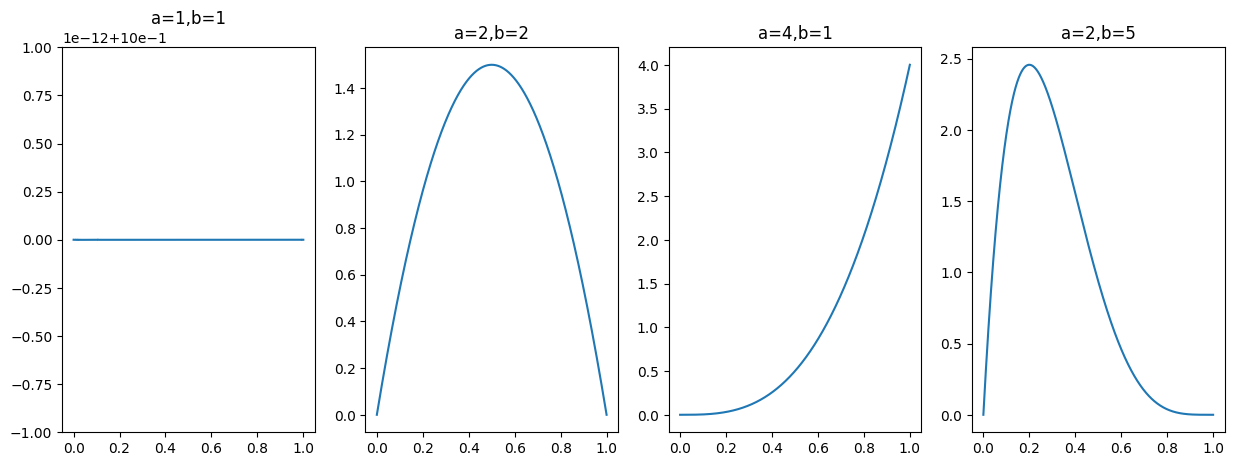

In [2]:
parameters = [(1,1), (2,2), (4,1),(2,5)]
x = np.linspace(0,1,1000)
plt.figure(figsize=(15, 5))
for idx, para in enumerate(parameters):
    plt.subplot(1, len(parameters), idx+1)
    y = beta.pdf(x, *para)
    plt.title(f'a={para[0]},b={para[1]}')
    plt.plot(x,y)

## The model

Here we define the probabilistic model. Notice the close resemblance with the plate specification above.

In [3]:
p_alpha = 2
p_beta = 5
# Defines the thumb_tack model. The 'data' is a 0-1 tensor of type float  
def thumb_tack_model(data):  
    
    # Define the random variable theta
    theta = pyro.sample("theta", dist.Beta(p_alpha,p_beta))
    
    # and now the plate holding the observations. The number of observations are determined by the data set 
    # supplied to the function
    with pyro.plate("thumb_tack_plate"):
        pyro.sample(f"obs", dist.Bernoulli(probs=theta), obs=data)

## The variational distribution

In Pyro the variational distribution is defined as a so-called guide. In this example our variational distribution is a beta distribution with parameters q_alpha and q_beta:

$$
q(\theta)= \mathit{Beta}(\theta | \alpha, \beta)
$$

In [4]:
def thumb_tack_guide(data):

    # We initialize the variational parameters q_alpha and q_beta to 1.0. Also, we constrain the parameters to be positive as per 
    # definition of the distribution
    q_alpha = pyro.param("q_alpha", torch.tensor(1.0), constraint=constraints.positive)
    q_beta = pyro.param("q_beta", torch.tensor(1.0), constraint=constraints.positive)

    # The name of the random variable of the variational distribution must match the name of the corresponding
    # variable in the model exactly.
    pyro.sample("theta", dist.Beta(q_alpha, q_beta))

## Learning

For optimizing the ELBO we rely on a standard stochastic gradient descent

In [10]:
def thumb_tack_learn(data, num_steps=1000):

    pyro.clear_param_store()

    # Define the ELBO and the optimization function
    elbo = pyro.infer.Trace_ELBO()
    svi = pyro.infer.SVI(model=thumb_tack_model,
                         guide=thumb_tack_guide,
                         optim=SGD({'lr':0.001}),
                         loss=elbo)

    # Perform a fixed number of gradient steps
    for step in range(num_steps):
        loss = svi.step(data)

        if step % 500 == 0:
            print(f"Loss for iteration {step}: {loss}")

## Analyze

Let's take a look at the learned variational distribution 

In [6]:
def thumb_tack_analyze(data):

    # Get the values of the variational parameters
    q_alpha = pyro.param("q_alpha").item()
    q_beta = pyro.param("q_beta").item()

    mean = q_alpha/(q_alpha + q_beta)
    std = q_alpha*q_beta/(((q_alpha+q_beta)**2)*(q_alpha + q_beta + 1.0))
    post_alpha = data[data==1].shape[0] + p_alpha
    post_beta = data[data==0].shape[0] + p_beta

    true_mean = (post_alpha)/(post_alpha+post_beta)
    true_std = (post_alpha)*(post_beta)/((post_alpha+post_beta)**2*(post_alpha+post_beta+1))

    print(f"q_alpha: {q_alpha}")
    print(f"q_beta: {q_beta}")

    print(f"Mean: {mean}")
    print(f"Standard deviation: {std}")
    print(f"True mean: {true_mean}")
    print(f"True standard deviation: {true_std}")


    x = np.linspace(0.0, 1.0, 1000)
    plt.plot(x, beta.pdf(x, q_alpha, q_beta), label='Variational dist.')
    plt.plot(x,beta.pdf(x, post_alpha,post_beta), label='True dist.')
    plt.legend()

## Perform experiments

In [7]:
# The data consists of 20 pin ups ('1') and 80 pin down ('0'). Squeeze is just used to compress the dimensions 
# from 2 to 1
#data = torch.cat((torch.ones(20, 1), torch.zeros(80, 1))).squeeze()
data = dist.Bernoulli(0.8).sample([100])

In [8]:
# Do learning
thumb_tack_learn(data, num_steps=5000)

Loss for iteration 0: 69.34325623512268
Loss for iteration 500: 61.87045907974243
Loss for iteration 1000: 60.92971706390381
Loss for iteration 1500: 61.33089208602905
Loss for iteration 2000: 61.38243865966797
Loss for iteration 2500: 61.87319850921631
Loss for iteration 3000: 61.930668354034424
Loss for iteration 3500: 61.82542657852173
Loss for iteration 4000: 61.45940637588501
Loss for iteration 4500: 61.58181858062744


## Show the results

q_alpha: 55.474185943603516
q_beta: 22.412342071533203
Mean: 0.7122436621237306
Standard deviation: 0.002598068809023785
True mean: 0.7102803738317757
True standard deviation: 0.001905390410936747


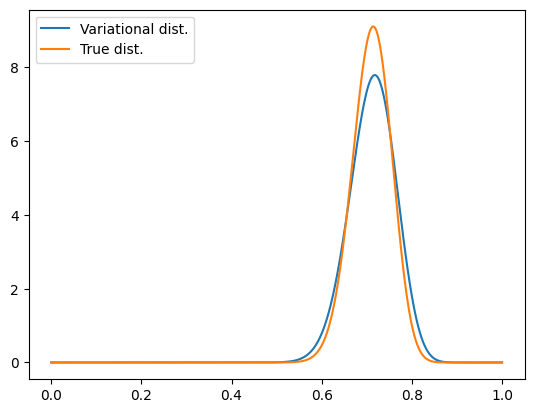

In [9]:
thumb_tack_analyze(data)